In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = r"/home/0283901/chu1/3D-Tensor-based-Deep-Learning-Models-for-Predicting-Option-Price-main/data/TXO_with_TXF.csv"

data = pd.read_csv(file_path)
data['date'] = pd.to_datetime(data['date'])
data['exdate'] = pd.to_datetime(data['exdate'])
data['opt_ID'] = data.groupby(by=['strike_price','exdate','PC']).ngroup()
data = data.sort_values(by=['opt_ID', 'date']).reset_index(drop=True)

data = data[data['date'] == '2021-12-30']
data = data[data['exdate'] == '2022-03-16']
data['PC'] = data['PC'].str.strip()
data = data[data['PC'] == 'C']
data


,date,exdate,option_price,strike_price,invm,tau,S,r,d,impl_volatility,volume,PC,opt_ID
253658,2021-12-30,2022-03-16,449.0,18200,1.004581,0.208219,18117,0.79,0,-1,2,C,6647
254925,2021-12-30,2022-03-16,352.0,18400,1.015621,0.208219,18117,0.79,0,-1,5,C,6681
255492,2021-12-30,2022-03-16,305.0,18500,1.021140,0.208219,18117,0.79,0,-1,1,C,6699
256193,2021-12-30,2022-03-16,256.0,18600,1.026660,0.208219,18117,0.79,0,-1,50,C,6714
257262,2021-12-30,2022-03-16,188.0,18800,1.037699,0.208219,18117,0.79,0,-1,4,C,6742
257677,2021-12-30,2022-03-16,167.0,18900,1.043219,0.208219,18117,0.79,0,-1,5,C,6757
258422,2021-12-30,2022-03-16,142.0,19000,1.048739,0.208219,18117,0.79,0,-1,5,C,6770
258777,2021-12-30,2022-03-16,120.0,19100,1.054258,0.208219,18117,0.79,0,-1,4,C,6784
259209,2021-12-30,2022-03-16,98.0,19200,1.059778,0.208219,18117,0.79,0,-1,21,C,6796
259819,2021-12-30,2022-03-16,65.0,19400,1.070817,0.208219,18117,0.79,0,-1,4,C,6821


In [3]:
file_path = r"/home/0283901/chu1/3D-Tensor-based-Deep-Learning-Models-for-Predicting-Option-Price-main/data/prs_dataset_new.csv"

data = pd.read_csv(file_path)
data['date'] = pd.to_datetime(data['date'])
data['exdate'] = pd.to_datetime(data['exdate'])
data = data.sort_values(by=['opt_ID', 'date']).reset_index(drop=True)

data = data[data['date'] == '2021-12-30']
data = data[data['exdate'] == '2022-03-16']
data = data[data['PC'] == 0]
data = data[['impl_volatility', 'invm', 'strike_price','option_price', 'S','tau']]
data

,impl_volatility,invm,strike_price,option_price,S,tau
37497,0.182255,0.894188,16200,2000.0,18117.0,0.208219
40430,0.181246,0.905227,16400,1820.0,18117.0,0.208219
43210,0.177187,0.916266,16600,1640.0,18117.0,0.208219
46140,0.170780,0.927306,16800,1460.0,18117.0,0.208219
49063,0.166967,0.938345,17000,1290.0,18117.0,0.208219
51917,0.164518,0.949385,17200,1130.0,18117.0,0.208219
54601,0.160812,0.960424,17400,975.0,18117.0,0.208219
56844,0.155775,0.971463,17600,825.0,18117.0,0.208219
58919,0.146061,0.982503,17800,670.0,18117.0,0.208219
59680,0.147116,0.988022,17900,615.0,18117.0,0.208219


[0.18225466 0.18124567 0.17718684 0.17078006 0.16696727 0.16451824
 0.16081226 0.15577496 0.14606084 0.14711561 0.14405813 0.14310064
 0.14386167 0.1414813  0.14080992 0.13814535 0.13365165 0.13214866
 0.13084022 0.13241759 0.13151542 0.13067809 0.12860671 0.12707511
 0.12580291 0.12944213 0.12546531 0.12529747 0.12535087 0.12589065
 0.12668983 0.12664787 0.1270961  0.12933341 0.13119308 0.13611594
 0.14068976 0.14508237 0.14953603 0.15395154 0.15855969 0.16308201]


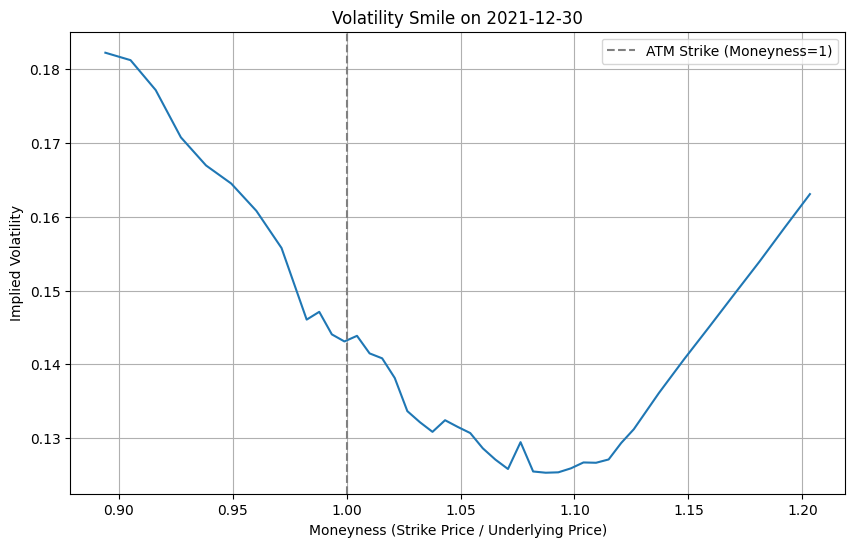

In [4]:
file_path = r"/home/0283901/chu1/3D-Tensor-based-Deep-Learning-Models-for-Predicting-Option-Price-main/data/prs_dataset_new.csv"

data = pd.read_csv(file_path)
data['date'] = pd.to_datetime(data['date'])
data['exdate'] = pd.to_datetime(data['exdate'])
data = data.sort_values(by=['opt_ID', 'date']).reset_index(drop=True)

data = data[data['date'] == '2021-12-30']
data = data[data['exdate'] == '2022-03-16']
data = data[data['PC'] == 0]
data = data[['impl_volatility', 'invm', 'strike_price','option_price', 'S']]
data['moneyness'] = data['strike_price'] / data['S']
data = data.sort_values(by=['moneyness']).reset_index(drop=True)

print(data['impl_volatility'].values)
plt.figure(figsize=(10, 6))
plt.plot(data['moneyness'].values,data['impl_volatility'].values)
plt.axvline(x=1, color='gray', linestyle='--', label='ATM Strike (Moneyness=1)')
plt.title("Volatility Smile on 2021-12-30")
plt.xlabel("Moneyness (Strike Price / Underlying Price)")
plt.ylabel("Implied Volatility")
plt.legend()
plt.grid()
plt.show()

[0.14386167 0.14080992 0.13814535 0.13365165 0.13084022 0.13241759
 0.13151542 0.13067809 0.12860671 0.12580291 0.12944213 0.12535087
 0.12668983 0.1270961  0.16308201]


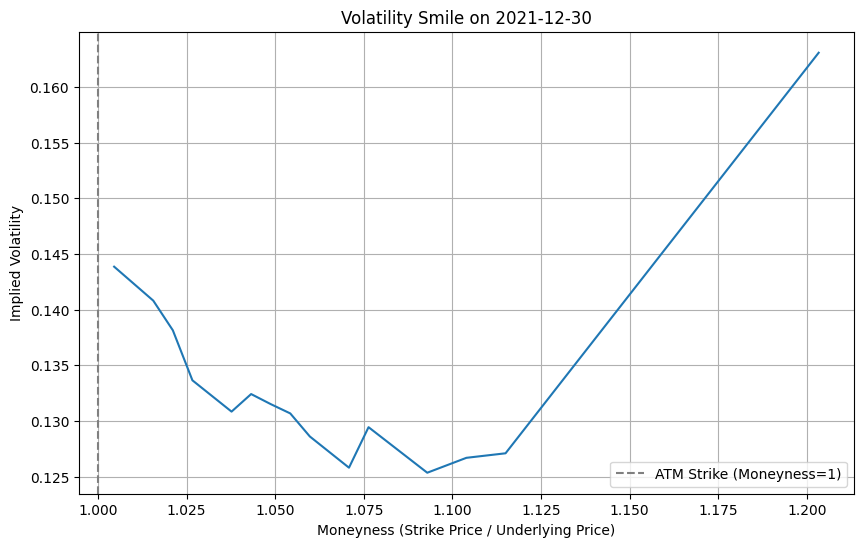

In [5]:
from functions import calculate_implied_volatility
file_path = r"/home/0283901/chu1/3D-Tensor-based-Deep-Learning-Models-for-Predicting-Option-Price-main/data/TXO_with_TXF.csv"

data = pd.read_csv(file_path)
data['date'] = pd.to_datetime(data['date'])
data['exdate'] = pd.to_datetime(data['exdate'])
data['r'] = data['r']/100
# 去除 PC 列中的前後空格
data['PC'] = data['PC'].str.strip()
data = data[data['date'] == '2021-12-30']
data = data[data['exdate'] == '2022-03-16']
data = data[data['PC'] == 'C']
data['impl_volatility'] = data.apply(calculate_implied_volatility, axis = 1)
data = data[['impl_volatility', 'invm', 'strike_price','option_price', 'S']]
data['moneyness'] = data['strike_price'] / data['S']
data = data.sort_values(by=['moneyness']).reset_index(drop=True)

print(data['impl_volatility'].values)
plt.figure(figsize=(10, 6))
plt.plot(data['moneyness'].values,data['impl_volatility'].values)
plt.axvline(x=1, color='gray', linestyle='--', label='ATM Strike (Moneyness=1)')
plt.title("Volatility Smile on 2021-12-30")
plt.xlabel("Moneyness (Strike Price / Underlying Price)")
plt.ylabel("Implied Volatility")
plt.legend()
plt.grid()
plt.show()